In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model27_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model27_0)
describe(model27_0)

MACs: 5.32 MMac, Params: 44.37 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.1373, Train accuracy = 0.5969, Test loss = 1.1180, Test accuracy = 0.6048
Epoch 2/60: Train loss = 0.9008, Train accuracy = 0.6794, Test loss = 0.8977, Test accuracy = 0.6812
Epoch 3/60: Train loss = 0.8338, Train accuracy = 0.7089, Test loss = 0.8524, Test accuracy = 0.7102
Epoch 4/60: Train loss = 0.7065, Train accuracy = 0.7521, Test loss = 0.7062, Test accuracy = 0.7519
Epoch 5/60: Train loss = 0.6560, Train accuracy = 0.7711, Test loss = 0.6666, Test accuracy = 0.7695
Epoch 6/60: Train loss = 0.6779, Train accuracy = 0.7643, Test loss = 0.6933, Test accuracy = 0.7697
Epoch 7/60: Train loss = 0.7097, Train accuracy = 0.7538, Test loss = 0.7609, Test accuracy = 0.7439
Epoch 8/60: Train loss = 0.5985, Train accuracy = 0.7897, Test loss = 0.6170, Test accuracy = 0.7844
Epoch 9/60: Train loss = 0.5543, Train accuracy = 0.8068, Test loss = 0.5892, Test accuracy = 0.7986
Epoch 10/60: Train loss = 0.5618, Train accuracy = 0.8033, Test loss = 0.5947, Test accurac

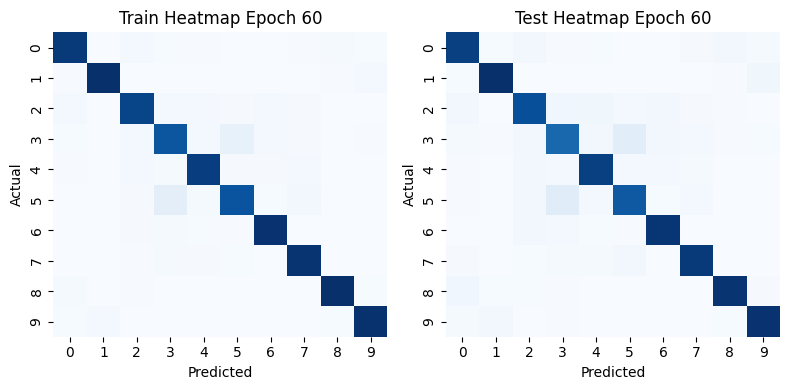

<Figure size 1200x600 with 0 Axes>

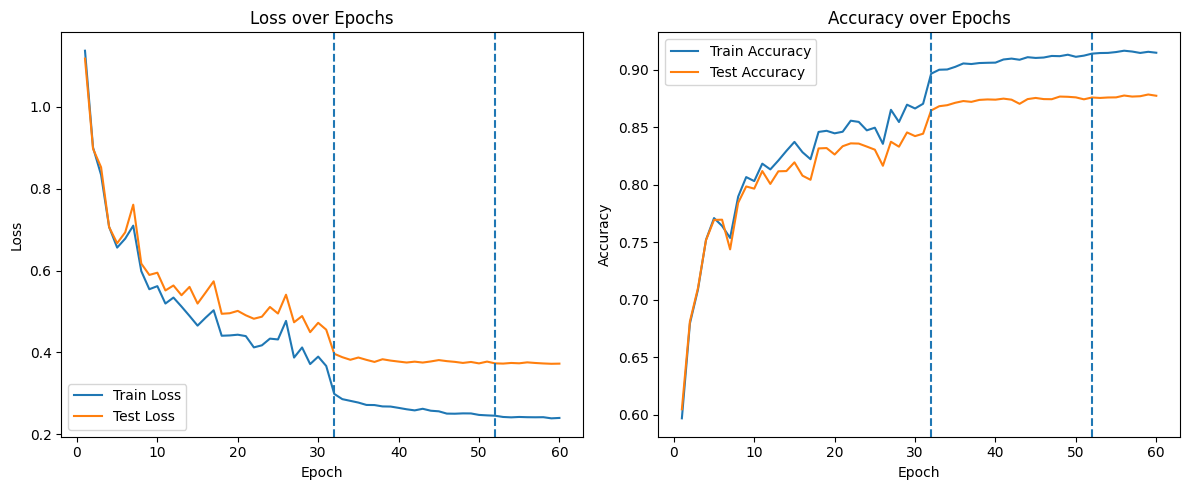

In [6]:
trainf32(model27_0,"model_weights/model27_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model27_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model27_1)
describe(model27_1)

MACs: 5.32 MMac, Params: 44.37 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 0.9292, Train accuracy = 0.6719, Test loss = 0.9037, Test accuracy = 0.6750
Epoch 2/60: Train loss = 0.8037, Train accuracy = 0.7198, Test loss = 0.7953, Test accuracy = 0.7223
Epoch 3/60: Train loss = 0.6827, Train accuracy = 0.7633, Test loss = 0.7021, Test accuracy = 0.7578
Epoch 4/60: Train loss = 0.6469, Train accuracy = 0.7729, Test loss = 0.6700, Test accuracy = 0.7662
Epoch 5/60: Train loss = 0.6221, Train accuracy = 0.7826, Test loss = 0.6521, Test accuracy = 0.7746
Epoch 6/60: Train loss = 0.6034, Train accuracy = 0.7892, Test loss = 0.6276, Test accuracy = 0.7841
Epoch 7/60: Train loss = 0.5676, Train accuracy = 0.8059, Test loss = 0.5960, Test accuracy = 0.7973
Epoch 8/60: Train loss = 0.5509, Train accuracy = 0.8091, Test loss = 0.6009, Test accuracy = 0.7979
Epoch 9/60: Train loss = 0.6347, Train accuracy = 0.7806, Test loss = 0.6847, Test accuracy = 0.7710
Epoch 10/60: Train loss = 0.5241, Train accuracy = 0.8157, Test loss = 0.5949, Test accurac

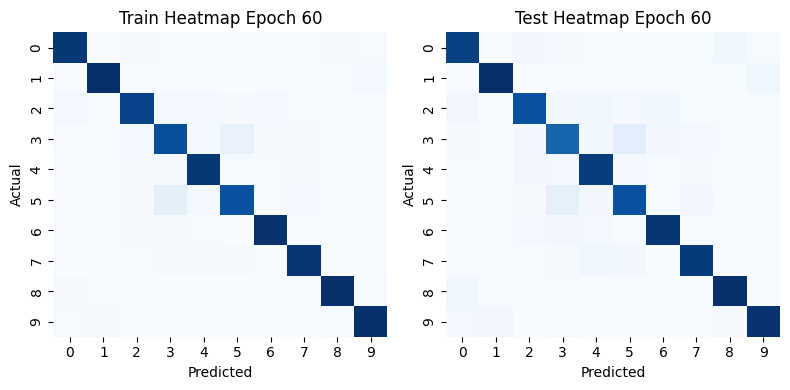

<Figure size 1200x600 with 0 Axes>

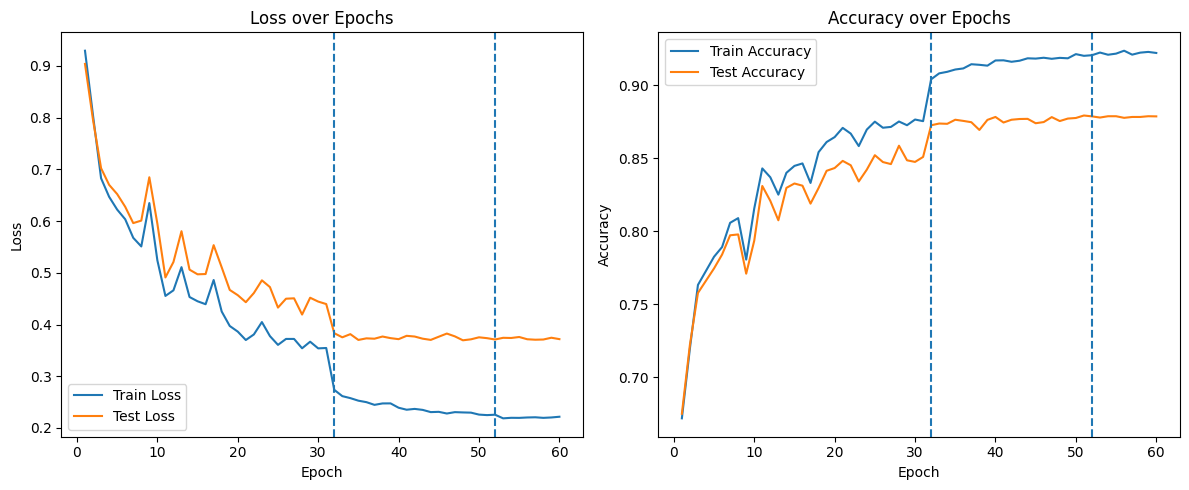

In [8]:
trainf32(model27_1,"model_weights/model27_1.pt",criterion,train_dataset,val_dataset, batch_size=64)